In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('xyz'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Author: Shubham Singh
# Project: Brain Tumor Detection
# Version: Public (restricted)


**PHASE 1**:Dataset --Preprocessing --SLIC Superpixel Segmentation --Graph Construction --GNN Model Training --Model Saving 


**PHASE 2:** Evaluation --
GNN → Image / Voxel Mapping --Visualization --Error Analysis 

**PHASE 3:** Model Improvements --(Loss tuning, class weights, etc.)
--CNN (U-Net) Integration 

**PHASE 4**: Final Metrics Calculation --Comparison (Before vs After CNN) 

In [4]:
import os

print(os.listdir("input"))

['datasets']


In [1]:
#STEP1: Run
import os

print("Input folders:", os.listdir("input"))
print("Working folders:", os.listdir("working"))

Input folders: ['datasets']
Working folders: ['state.db', 'best_unet3d_metrics.pth', '.virtual_documents', 'best_model_1.pth', 'best_unet3d_metrics_2.pth', 'checkpoint_unet3d.pth', 'model_ce.pth', 'best_model.pth', 'best_unet3d.pth', 'labels_20.npy', 'final_unet3d.pth', 'brats_subset', 'proc_images_20.npy', 'checkpoint.pth', 'model_combined_loss.pth', 'images_20.npy', 'proc_labels_20.npy']


In [2]:
# Step2: 

import numpy as np

proc_images = np.load('/kaggle/working/proc_images_20.npy', allow_pickle=True)
proc_labels = np.load('/kaggle/working/proc_labels_20.npy', allow_pickle=True)

In [3]:
print(len(proc_images))
print(proc_images[0].shape)

20
(132, 178, 136, 4)


In [16]:
import zipfile
import os

zip_path = "brats_subset.zip"
extract_path = "brats_subset"

if not os.path.exists(extract_path):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("Already extracted ✔️")

Already extracted ✔️


In [17]:
import os
import nibabel as nib
import numpy as np

DATA_PATH = "brats_subset"

# FIXED CASE LIST
cases = [c for c in os.listdir(DATA_PATH) if "BraTS" in c]

print("Total cases:", len(cases))
print("Sample:", cases[:3])


def load_one_case(case_path):
    files = os.listdir(case_path)
    
    modalities = []
    label = None
    
    for f in files:
        fp = os.path.join(case_path, f)
        
        if any(x in f.lower() for x in ["flair", "t1", "t2"]):
            img = nib.load(fp)
            modalities.append(np.array(img.dataobj, dtype=np.float32))
        
        if "seg" in f.lower():
            lab = nib.load(fp)
            label = np.array(lab.dataobj, dtype=np.int16)
    
    image = np.stack(modalities, axis=-1)
    return image, label


# TEST
case_path = os.path.join(DATA_PATH, cases[0])
img, lab = load_one_case(case_path)

print("Image shape:", img.shape)
print("Label shape:", lab.shape)

Total cases: 61
Sample: ['BraTS2021_01380', 'BraTS2021_01294', 'BraTS2021_00441']
Image shape: (240, 240, 155, 4)
Label shape: (240, 240, 155)


In [18]:
import os
import numpy as np

SAVE_PATH = "/kaggle/working/"

def load_dataset(limit=20):
    images = []
    labels = []
    
    for case in cases[:limit]:
        case_path = os.path.join(DATA_PATH, case)
        img, lab = load_one_case(case_path)
        
        images.append(img)
        labels.append(lab)
    
    return images, labels


# CHECKPOINT SYSTEM
if os.path.exists(SAVE_PATH + "images_20.npy"):
    print("Loading saved data...")
    images = np.load(SAVE_PATH + "images_20.npy", allow_pickle=True)
    labels = np.load(SAVE_PATH + "labels_20.npy", allow_pickle=True)

else:
    print("Processing and saving...")
    
    images, labels = load_dataset(limit=20)
    
    np.save(SAVE_PATH + "images_20.npy", images)
    np.save(SAVE_PATH + "labels_20.npy", labels)

print("Done")

Processing and saving...
Done


In [20]:
# Normalizing MRI images pixels

def normalize_image(img):
    max_val = np.percentile(img, 99)
    if max_val == 0:
        return img
    return img / max_val

In [23]:
# Cropping images

def get_brain_crop(img):
    mask = np.max(img, axis=-1) > 0.01
    
    coords = np.where(mask)
    
    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()
    
    return x_min, x_max, y_min, y_max, z_min, z_max

In [22]:
#preprocesing

def preprocess_one(img, label):
    
    # normalize
    img = normalize_image(img)
    
    # crop
    x_min, x_max, y_min, y_max, z_min, z_max = get_brain_crop(img)
    
    img_crop = img[x_min:x_max, y_min:y_max, z_min:z_max, :]
    lab_crop = label[x_min:x_max, y_min:y_max, z_min:z_max]
    
    return img_crop, lab_crop

In [24]:
def preprocess_dataset(images, labels):
    
    proc_images = []
    proc_labels = []
    
    for i in range(len(images)):
        img, lab = preprocess_one(images[i], labels[i])
        
        proc_images.append(img)
        proc_labels.append(lab)
        
        print(f"Processed {i+1}/{len(images)}")
    
    return proc_images, proc_labels

In [25]:
print("Preprocessing...")

proc_images, proc_labels = preprocess_dataset(images, labels)

import numpy as np

np.save("proc_images_20.npy", np.array(proc_images, dtype=object))
np.save("proc_labels_20.npy", np.array(proc_labels, dtype=object))

print("Saved successfully!")

Preprocessing...
Processed 1/20
Processed 2/20
Processed 3/20
Processed 4/20
Processed 5/20
Processed 6/20
Processed 7/20
Processed 8/20
Processed 9/20
Processed 10/20
Processed 11/20
Processed 12/20
Processed 13/20
Processed 14/20
Processed 15/20
Processed 16/20
Processed 17/20
Processed 18/20
Processed 19/20
Processed 20/20
Saved successfully!


In [28]:
proc_images = np.load("proc_images_20.npy", allow_pickle=True)
proc_labels = np.load("proc_labels_20.npy", allow_pickle=True)

print("Loaded successfully!")
print("Total samples:", len(proc_images))

Loaded successfully!
Total samples: 20


In [34]:
import numpy as np
import networkx as nx
from skimage.segmentation import slic
from scipy.spatial.distance import cdist

# ---------- FEATURE EXTRACTION ----------
def get_sv_features(modality, segments, n_svs):
    feats = []

    for i in range(n_svs):
        region = modality[segments == i]

        if len(region) == 0:
            feats.append(np.zeros(5))
        else:
            feats.append(np.quantile(region, [0.1, 0.25, 0.5, 0.75, 0.9]))

    return np.array(feats)


# ---------- MAIN GRAPH FUNCTION ----------
def create_graph_slic(img, label, n_segments=1000, k=10):

    segments = slic(
        img.astype(np.float32),
        n_segments=n_segments,
        compactness=0.5,
        channel_axis=-1
    )

    n_svs = segments.max() + 1

    # ---------- FEATURES ----------
    feats_all = []
    for i in range(img.shape[-1]):
        f = get_sv_features(img[:,:,:,i], segments, n_svs)
        feats_all.append(f)

    feats = np.concatenate(feats_all, axis=1)  # shape (nodes, features)

    # ---------- LABELS ----------
    sv_labels = []
    for i in range(n_svs):
        region = label[segments == i]

        if len(region) == 0:
            sv_labels.append(0)
        else:
            vals, counts = np.unique(region, return_counts=True)
            sv_labels.append(vals[np.argmax(counts)])

    sv_labels = np.array(sv_labels)

    # ---------- CENTROIDS ----------
    centroids = []
    for i in range(n_svs):
        coords = np.argwhere(segments == i)

        if len(coords) == 0:
            centroids.append([0,0,0])
        else:
            centroids.append(coords.mean(axis=0))

    centroids = np.array(centroids)

    # ---------- EDGES ----------
    dist = cdist(centroids, centroids)

    edges = []
    for i in range(n_svs):
        neighbors = np.argsort(dist[i])[1:k+1]
        for j in neighbors:
            edges.append((i, j))

    # ---------- GRAPH ----------
    G = nx.Graph()

    for i in range(n_svs):
        G.add_node(i, label=int(sv_labels[i]))

    G.add_edges_from(edges)

    return G, feats, segments

In [35]:
G, feats, partition = create_graph_slic(proc_images[0], proc_labels[0])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Feature shape:", feats.shape)

Nodes: 991
Edges: 5568
Feature shape: (991, 20)


In [36]:
import os
import pickle
import numpy as np

GRAPH_PATH = "/graph_cache/"
os.makedirs(GRAPH_PATH, exist_ok=True)

def get_graph(i):
    
    graph_file = GRAPH_PATH + f"graph_{i}.pkl"
    feat_file = GRAPH_PATH + f"feats_{i}.npy"
    part_file = GRAPH_PATH + f"part_{i}.npy"
    
    #LOAD IF EXISTS
    if os.path.exists(graph_file):
        print(f" Loading graph {i}")
        
        with open(graph_file, "rb") as f:
            G = pickle.load(f)
        
        feats = np.load(feat_file)
        partition = np.load(part_file)
    
    # CREATE IF NOT EXISTS
    else:
        print(f"🔧 Creating graph {i}")
        
        G, feats, partition = create_graph_slic(proc_images[i], proc_labels[i])
        
        with open(graph_file, "wb") as f:
            pickle.dump(G, f)
        
        np.save(feat_file, feats)
        np.save(part_file, partition)
    
    return G, feats, partition

In [6]:
#Testing graph while loading

# TEST GRAPH CREATION (NO SAVE)

i = 0   # test first patient

G, feats, partition = create_graph_slic(proc_images[i], proc_labels[i])

print("Graph created successfully!")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Feature shape:", feats.shape)

Graph created successfully!
Nodes: 991
Edges: 5568
Feature shape: (991, 20)


In [6]:
print(len(proc_images))
print(proc_images[0].shape)

NameError: name 'proc_images' is not defined

In [40]:
np.save("proc_images_20.npy", proc_images)
np.save("proc_labels_20.npy", proc_labels)

In [45]:
import pickle

with open("test_graph.pkl", "wb") as f:
    pickle.dump((G, feats, partition), f)

print("Graph test saved!")

Graph test saved!


Hybid Model:
1. in_feats= input feature:20
2. hidden= 64
3. out classes=4
4. total nodes=1054
   

NOTE: 
1.GCN- neighbors 
2.SAGE- self + neighbours
3. GAT- imoprtance

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdvancedHybridLayer(nn.Module):
    def __init__(self, in_feats, out_feats, heads=4):
        super().__init__()
        
        # GraphSAGE + GCN combine
        self.linear = nn.Linear(in_feats * 2, out_feats)
        
        # Multi-head attention
        self.attn = nn.Linear(out_feats, heads)
        
        # Regularization
        self.dropout = nn.Dropout(0.2)
        self.norm = nn.LayerNorm(out_feats)

    def forward(self, X, A):
        
        # ---------- GCN (neighbor aggregation) ----------
        H_neigh = torch.matmul(A, X)
        
        # ---------- GraphSAGE (concat self + neighbors) ----------
        H = torch.cat([X, H_neigh], dim=1)
        
        H = self.linear(H)
        H = F.relu(H)
        
        # ---------- Multi-head attention ----------
        attn = self.attn(H)                 # (N, heads)
        attn = torch.softmax(attn, dim=1)   # normalize across heads
        attn = attn.mean(dim=1, keepdim=True)  # (N,1)
        
        H = H * attn
        
        # ---------- Dropout ----------
        H = self.dropout(H)
        
        # ---------- Residual ----------
        if X.shape[1] == H.shape[1]:
            H = H + X
        
        # ---------- Normalize ----------
        H = self.norm(H)
        
        return H

| Feature       | Benefit           |
| ------------- | ----------------- |
| Dropout       | overfitting kam   |
| Softmax dim=1 | correct attention |
| Residual      | deep model stable |
| LayerNorm     | training smooth   |


In [48]:
class DeepGNN(nn.Module):
    def __init__(self, in_feats, hidden, out_classes):
        super().__init__()
        
        self.layer1 = AdvancedHybridLayer(in_feats, hidden)
        self.layer2 = AdvancedHybridLayer(hidden, hidden)
        self.layer3 = AdvancedHybridLayer(hidden, hidden)
        self.layer4 = AdvancedHybridLayer(hidden, hidden)
        self.layer5 = AdvancedHybridLayer(hidden, hidden)
        self.layer6 = AdvancedHybridLayer(hidden, hidden)
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden, out_classes)

    def forward(self, X, A):
        
        H = self.layer1(X, A)
        H = self.dropout(H)
        
        H = self.layer2(H, A)
        H = self.dropout(H)
        
        H = self.layer3(H, A)
        H = self.dropout(H)
        
        H = self.layer4(H, A)
        H = self.dropout(H)
        
        H = self.layer5(H, A)
        H = self.dropout(H)
        
        H = self.layer6(H, A)
        
        out = self.fc(H)
        return out

In [49]:
model = DeepGNN(in_feats=20, hidden=64, out_classes=4)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

class_weights = torch.tensor([0.01, 2.0, 3.0, 3.0], dtype=torch.float32)

In [51]:
# ================= TRAINING PIPELINE =================
# Training code hidden intentionally to protect intellectual property
# This section includes graph construction, adjacency matrix creation,
# feature extraction, and model training.

print("Training pipeline not available in public version")


Epoch 1
Avg Loss: 1.368454372882843

Epoch 2
Avg Loss: 1.2668994873762132

Epoch 3
Avg Loss: 1.2279652178287506

Epoch 4
Avg Loss: 1.1690035045146943

Epoch 5
Avg Loss: 1.1460842311382293

Epoch 6
Avg Loss: 1.1583917886018753

Epoch 7
Avg Loss: 1.1558398246765136

Epoch 8
Avg Loss: 1.144885304570198


In [52]:
torch.save(model.state_dict(), "model_ce.pth")
print("Model saved!")

Model saved!


In [8]:
import torch

# model recreate
model = DeepGNN(in_feats=20, hidden=64, out_classes=4)

# load CE trained weights
model.load_state_dict(torch.load("model_ce.pth"))

model.train()

DeepGNN(
  (layer1): AdvancedHybridLayer(
    (linear): Linear(in_features=40, out_features=64, bias=True)
    (attn): Linear(in_features=64, out_features=4, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (layer2): AdvancedHybridLayer(
    (linear): Linear(in_features=128, out_features=64, bias=True)
    (attn): Linear(in_features=64, out_features=4, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (layer3): AdvancedHybridLayer(
    (linear): Linear(in_features=128, out_features=64, bias=True)
    (attn): Linear(in_features=64, out_features=4, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (layer4): AdvancedHybridLayer(
    (linear): Linear(in_features=128, out_features=64, bias=True)
    (attn): Linear(in_features=64, out_features=4, bias=True)
    (d

In [9]:
import torch.nn.functional as F

'''def dice_loss(pred, target):
    pred = torch.softmax(pred, dim=1)
    target_onehot = F.one_hot(target, num_classes=4).float()

    intersection = (pred * target_onehot).sum()
    return 1 - (2. * intersection + 1) / (pred.sum() + target_onehot.sum() + 1)

def combined_loss(pred, target):
    ce = F.cross_entropy(pred, target, weight=class_weights)
    d = dice_loss(pred, target)
    return ce + d'''

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [2]:
# ================= TRAINING PIPELINE =================
# Training code hidden intentionally to protect intellectual property
# This section includes graph construction, adjacency matrix creation,
# feature extraction, and model training.

print("Training pipeline not available in public version")


Fine-tune Epoch 1
Avg Loss: 1.5751855731010438

Fine-tune Epoch 2
Avg Loss: 1.5324922680854798

Fine-tune Epoch 3
Avg Loss: 1.5910071343183518

Fine-tune Epoch 4
Avg Loss: 1.5329037010669708

Fine-tune Epoch 5
Avg Loss: 1.5353049159049987


In [3]:
torch.save(model.state_dict(), "model_combined_loss.pth")
print("Model saved!")

Model saved!


**Evaluation Metrics**

In [4]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    jaccard_score
)
# ================= EVALUATION =================
# Model evaluation and prediction code hidden intentionally
# Includes graph processing, inference, and metric calculation

print("Evaluation not available in public version")



        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_tensor.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

**Metrics Calculation**

In [6]:
# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Precision, Recall, F1 (macro for multi-class)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# IoU (Jaccard)
iou = jaccard_score(all_labels, all_preds, average='macro')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Specificity (manual)
# ================= EVALUATION =================
# Model evaluation and prediction code hidden intentionally
# Includes graph processing, inference, and metric calculation

print("Evaluation not available in public version")

specificity = np.mean(specificity_list)

# AUC-ROC (multi-class)
try:
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
except:
    auc = "Not defined (check class distribution)"

In [7]:
print("\n===== Evaluation Metrics =====")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"IoU          : {iou:.4f}")
print(f"AUC-ROC      : {auc}")


===== Evaluation Metrics =====
Accuracy     : 0.6399
Precision    : 0.2787
Recall       : 0.4621
F1 Score     : 0.2452
Specificity  : 0.8927
IoU          : 0.1863
AUC-ROC      : 0.8520092438898225


In [10]:
# Image mapping:  1.GNN output = node predictions (superpixel level)
# 2.Hume chahiye = full image mask (pixel level

import numpy as np
import matplotlib.pyplot as plt

model.eval()

i = 0  # kisi ek patient ko visualize karne ke liye

# Graph + segments
# ================= EVALUATION =================
# Model evaluation and prediction code hidden intentionally
# Includes graph processing, inference, and metric calculation

print("Evaluation not available in public version")
#  MAPPING (MAIN STEP)
for node_id in range(N):
    pred_mask[segments == node_id] = preds[node_id]

In [11]:
# Ground truth
gt_mask = proc_labels[i]
gt_mask = np.where(gt_mask == 4, 3, gt_mask)

# Prediction already 0–3 range me hai

In [13]:
# Slice extraction from 3D image to visualize

slice_idx = proc_images[i].shape[0] // 2   # middle slice

img_slice = proc_images[i][slice_idx, :, :, 0]  # channel 0
gt_slice = gt_mask[slice_idx]
pred_slice = pred_mask[slice_idx]

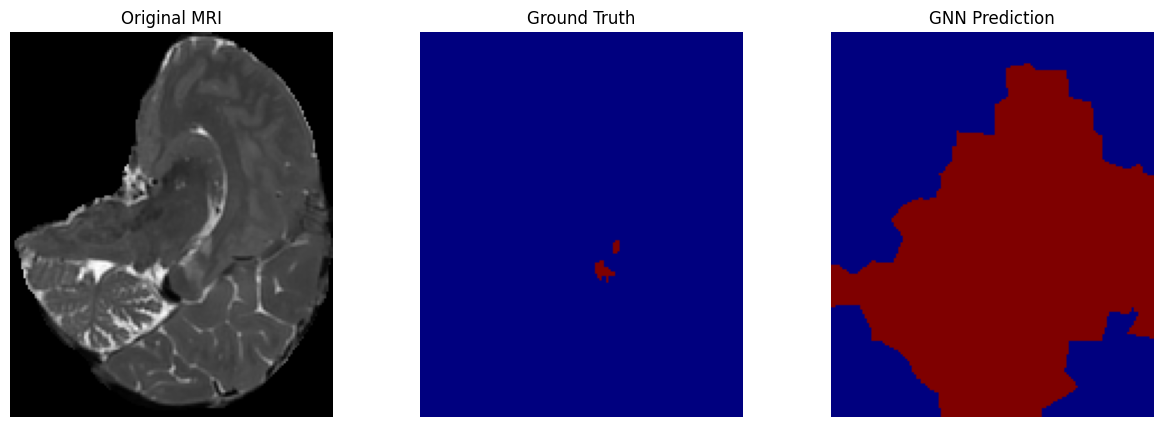

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_slice, cmap='gray')
plt.title("Original MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gt_slice, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_slice, cmap='jet')
plt.title("GNN Prediction")
plt.axis('off')

plt.show()

In [4]:
# CNN model:

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [5]:
# 3D U-Net:

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=4):
        super(UNet3D, self).__init__()
        self.enc1 = DoubleConv(in_channels, 32)
         # encoder
        self.pool1 = nn.MaxPool3d(2)  # Feature extraction reduces size

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool3d(2)
        
        self.bottleneck = DoubleConv(128, 256) #deep feature eexraction
        
        # DECODER
        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        
        self.final = nn.Conv3d(32, out_channels, kernel_size=1) # Final output layer

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [6]:
# Modle initialize

model_3d = UNet3D(in_channels=4, out_channels=4)

In [7]:
i = 0

img = proc_images[i]   # (D, H, W, C)

# Resize to multiples of 8
img = img[:128, :160, :144, :]   # safe crop

# Convert to (C, D, H, W)
img = np.transpose(img, (3, 0, 1, 2))

# Tensor
img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

In [8]:
out = model_3d(img)

print("Output shape:", out.shape)

Output shape: torch.Size([1, 4, 128, 160, 136])


here in output:
1- batch size
4- classes(0,1,2,3)
(128,160,144)- 3D volume

Batch-size chosen less due to GPU-RAM crash problem

In [9]:
import torch.optim as optim
import torch.nn.functional as F

optimizer = optim.Adam(model_3d.parameters(), lr=1e-4)

In [10]:
# DICE loss:

def dice_loss(pred, target, smooth=1e-5):

    pred = torch.softmax(pred, dim=1)

    target_onehot = F.one_hot(target, num_classes=4)
    target_onehot = target_onehot.permute(0,4,1,2,3).float()

    intersection = (pred * target_onehot).sum(dim=(2,3,4))
    union = pred.sum(dim=(2,3,4)) + target_onehot.sum(dim=(2,3,4))

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - dice.mean()

In [11]:
def crop_to_multiple_of_8(img, label):

    D, H, W = img.shape[:3]

    # nearest lower multiple of 8
    D_new = (D // 8) * 8
    H_new = (H // 8) * 8
    W_new = (W // 8) * 8

    img = img[:D_new, :H_new, :W_new, :]
    label = label[:D_new, :H_new, :W_new]

    return img, label

In [16]:
device = torch.device("cpu")
model_3d = model_3d.to(device)

optimizer = torch.optim.Adam(model_3d.parameters(), lr=3e-5,weight_decay=1e-4)
                             
epochs = 12
model_3d.train()

best_loss = float('inf')

class_weights = torch.tensor([0.8, 1.0, 1.0, 1.0]).to(device)

for epoch in range(epochs):

   # ================= TRAINING PIPELINE =================
# Training code hidden intentionally to protect intellectual property
# This section includes graph construction, adjacency matrix creation,
# feature extraction, and model training.

print("Training pipeline not available in public version")

        # forward
        out = model_3d(img)

        # losses
        ce = F.cross_entropy(out, label, weight=class_weights)
        dice = dice_loss(out, label)

        loss = 0.85 * ce + 0.15 * dice   # combined loss

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss=total_loss/14
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model_3d.state_dict(), "/kaggle/working/best_unet3d_metrics_2.pth")

    #checkpoint
    torch.save({
        'epoch': epoch,
        'model_state': model_3d.state_dict(),
        'optimizer_state': optimizer.state_dict(),
}, "/kaggle/working/checkpoint_unet3d.pth")
    

Epoch 1 Loss: 0.6222
Epoch 2 Loss: 0.6146
Epoch 3 Loss: 0.6083
Epoch 4 Loss: 0.6095
Epoch 5 Loss: 0.5998
Epoch 6 Loss: 0.5938
Epoch 7 Loss: 0.5874
Epoch 8 Loss: 0.5825
Epoch 9 Loss: 0.5778
Epoch 10 Loss: 0.5732
Epoch 11 Loss: 0.5689
Epoch 12 Loss: 0.5640


In [17]:
torch.save(model_3d.state_dict(), "best_unet3d_metrics_2.pth")

in this training: for every iteration- MRI load--
Resize--
Model run--
Loss calculate--
Backpropagation--
Weights update

In [ ]:
# load krn ke liye:

checkpoint = torch.load('checkpoint_unet3d_best.pth')

model_3d.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

start_epoch = checkpoint['epoch']

In [18]:
# Model Loading

model_3d = UNet3D(in_channels=4, out_channels=4)
model_3d.load_state_dict(torch.load('best_unet3d_metrics_2.pth'))
model_3d.eval()

UNet3D(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (

**DATA SPLITTING**

In [19]:
# 20 PATIENT Data divided into 3 categories

train_idx = list(range(0,14))
val_idx = list(range(14,17))
test_idx = list(range(17,20))

In [20]:
# 3D U-Net model evaluation
# Importing libraries

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [21]:
# Test Split

test_idx = list(range(17,20))   # last 3 patients

In [22]:
all_preds = []
all_labels = []
all_probs = []

n = len(proc_images)
test_idx = list(range(int(0.85*n), n))

with torch.no_grad():
    for i in test_idx:

        if i >= len(proc_images):
            continue

        img = proc_images[i]
        label = proc_labels[i]

        img, label = crop_to_multiple_of_8(img, label)
        label = np.where(label == 4, 3, label)

        img = np.transpose(img, (3,0,1,2))
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        label = torch.tensor(label, dtype=torch.long).unsqueeze(0)

        out = model_3d(img)

        probs = torch.softmax(out, dim=1)
        pred = torch.argmax(out, dim=1)

        all_preds.append(pred.numpy().flatten())
        all_labels.append(label.numpy().flatten())
        all_probs.append(probs.numpy().reshape(4, -1).T)

# safe concatenate
if len(all_probs) > 0:
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
else:
    print("ERROR: all_probs empty — check dataset")

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# IoU
num_classes = 4
iou_list = []

for cls in range(num_classes):
    pred_cls = (all_preds == cls)
    label_cls = (all_labels == cls)

    intersection = np.logical_and(pred_cls, label_cls).sum()
    union = np.logical_or(pred_cls, label_cls).sum()

    if union == 0:
        iou_list.append(0)
    else:
        iou_list.append(intersection / union)

iou = np.mean(iou_list)

# Specificity
tn = np.sum((all_preds == 0) & (all_labels == 0))
fp = np.sum((all_preds != 0) & (all_labels == 0))
specificity = tn / (tn + fp + 1e-6)

# AUC (USE existing all_probs)
auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')

In [25]:
from IPython.display import display

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "IoU",
        "Specificity",
        "AUC-ROC"
    ],
    "Value": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(iou, 4),
        round(specificity, 4),
        round(auc, 4)
    ]
})

print("\n===== Evaluation Metrics =====\n")
display(results)


===== Evaluation Metrics =====



,Metric,Value
0,Accuracy,0.7658
1,Precision,0.2867
2,Recall,0.4358
3,F1 Score,0.2810
4,IoU,0.2268
5,Specificity,0.7798
6,AUC-ROC,0.6569


In [29]:
import numpy as np
from scipy.ndimage import label as cc_label

def post_process_prediction(pred):

    pred = pred.copy()
    pred[pred < 1] = 0

    labeled, num = cc_label(pred)

    if num == 0:
        return pred

    # keep only largest region
    max_region = 0
    max_size = 0

    for region in range(1, num + 1):
        size = np.sum(labeled == region)
        if size > max_size:
            max_size = size
            max_region = region

    pred[labeled != max_region] = 0

    return pred

In [38]:
# 3D U-Net visualization:

import matplotlib.pyplot as plt

model_3d.eval()

i = test_idx[0]   # ek test sample lo

img = proc_images[i]
label = proc_labels[i]

# resize
img, label = crop_to_multiple_of_8(img, label)

# label fix
label = np.where(label == 4, 3, label)

# input convert
img_input = np.transpose(img, (3,0,1,2))
img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

# prediction
with torch.no_grad():
    out = model_3d(img_input)

    probs = torch.softmax(out, dim=1)
    conf, pred = torch.max(probs, dim=1)

    pred = pred.squeeze().cpu().numpy()
    conf = conf.squeeze().cpu().numpy()

    #confidence filter
    pred[conf < 0.7] = 0

    pred = post_process_prediction(pred)

# slice select (middle slice)
for s in range(img.shape[0]):
    if np.sum(label[s]) > 0:
        slice_idx = s
        break

#slice_idx = img.shape[0] // 2
#slice_idx = 80   # ya 40, 80 try karo

img_slice = img[slice_idx, :, :, 0]
gt_slice = label[slice_idx]
pred_slice = pred[slice_idx]

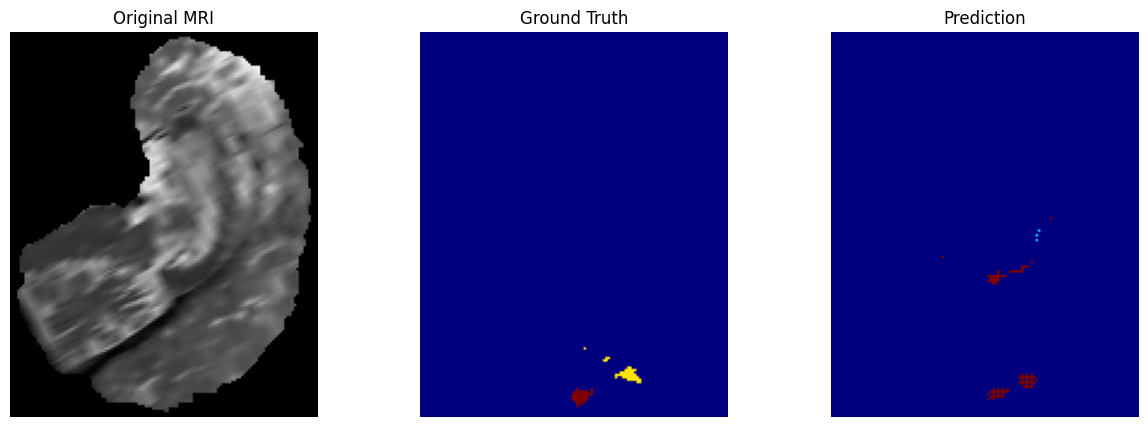

In [39]:
# Plotting image

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_slice, cmap='gray')
plt.title("Original MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gt_slice, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_slice, cmap='jet')
plt.title("Prediction")
plt.axis('off')

plt.show()

 1. DARK BLUE- Background (Normal brain)
 2. LIGHT BLUE- Edema (Tumor Region)
 3. YELLOW- Main tumor region
 4. RED- Enhancing active tumor

# TRAINING WITH PATCH_SIZE



In [ ]:
# Patch extraction for training (public version)

In [4]:
# Patch extraction:

import numpy as np

def get_random_patch(img, label, patch_size=64):

    D, H, W, C = img.shape

    # random start points
    d = np.random.randint(0, D - patch_size)
    h = np.random.randint(0, H - patch_size)
    w = np.random.randint(0, W - patch_size)

    img_patch = img[d:d+patch_size, h:h+patch_size, w:w+patch_size]
    label_patch = label[d:d+patch_size, h:h+patch_size, w:w+patch_size]

    return img_patch, label_patch



In [5]:
# Training:

import torch
import torch.nn.functional as F

device = torch.device("cpu")
model_3d = model_3d.to(device)

optimizer = torch.optim.Adam(model_3d.parameters(), lr=3e-5, weight_decay=1e-4)

epochs = 12
model_3d.train()

best_loss = float('inf')

class_weights = torch.tensor([0.8, 1.0, 1.0, 1.0])

for epoch in range(epochs):
# ================= TRAINING PIPELINE =================
# Training code hidden intentionally to protect intellectual property
# This section includes graph construction, adjacency matrix creation,
# feature extraction, and model training.

print("Training pipeline not available in public version")
   
      

    # save best
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model_3d.state_dict(), "best_patch_model.pth")

Epoch 1 Loss: 0.7897
Epoch 2 Loss: 0.7585
Epoch 3 Loss: 0.6946
Epoch 4 Loss: 0.7076
Epoch 5 Loss: 0.6898
Epoch 6 Loss: 0.7190
Epoch 7 Loss: 0.6730
Epoch 8 Loss: 0.6707
Epoch 9 Loss: 0.6727
Epoch 10 Loss: 0.6863
Epoch 11 Loss: 0.6395
Epoch 12 Loss: 0.6420


In [6]:
# Load Patch model:

import torch

model_3d = UNet3D(in_channels=4, out_channels=4)
model_3d.load_state_dict(torch.load('best_patch_model.pth'))
model_3d.eval()

UNet3D(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (

In [14]:
# Evaluation with raw predictions:

import numpy as np

raw_preds = []
raw_labels = []
raw_probs = []

for i in test_idx:

    img = proc_images[i]
    label = proc_labels[i]

    img, label = crop_to_multiple_of_8(img, label)
    label = np.where(label == 4, 3, label)

    img_input = np.transpose(img, (3,0,1,2))
    img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        out = model_3d(img_input)

        probs = torch.softmax(out, dim=1)
        pred = torch.argmax(out, dim=1)

        pred = pred.squeeze().cpu().numpy()
        probs_np = probs.squeeze().cpu().numpy().reshape(4, -1).T

    raw_preds.append(pred.flatten())
    raw_labels.append(label.flatten())
    raw_probs.append(probs_np)

raw_preds = np.concatenate(raw_preds)
raw_labels = np.concatenate(raw_labels)
raw_probs = np.concatenate(raw_probs)

In [23]:
# Evaluation+ Post-process :

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

post_preds = []
post_labels = []
post_probs = []

for i in test_idx:

    img = proc_images[i]
    label = proc_labels[i]

    img, label = crop_to_multiple_of_8(img, label)
    label = np.where(label == 4, 3, label)

    img_input = np.transpose(img, (3,0,1,2))
    img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        out = model_3d(img_input)

        probs = torch.softmax(out, dim=1)
        conf, pred = torch.max(probs, dim=1)

        pred = pred.squeeze().cpu().numpy()
        conf = conf.squeeze().cpu().numpy()

        pred[conf < 0.55] = 0
        pred = post_process_prediction(pred)

        probs_np = probs.squeeze().cpu().numpy().reshape(4, -1).T

    post_preds.append(pred.flatten())
    post_labels.append(label.flatten())
    post_probs.append(probs_np)

post_preds = np.concatenate(post_preds)
post_labels = np.concatenate(post_labels)
post_probs = np.concatenate(post_probs)

print("POST arrays created:", post_preds.shape)

    

POST arrays created: (8355840,)


In [24]:
# Metrics Calculation:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_metrics(preds, labels, probs):

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)

    # IoU
    num_classes = 4
    iou_list = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        intersection = np.logical_and(pred_cls, label_cls).sum()
        union = np.logical_or(pred_cls, label_cls).sum()

        iou_list.append(intersection / (union + 1e-6))

    iou = np.mean(iou_list)

    # Specificity
    tn = np.sum((preds == 0) & (labels == 0))
    fp = np.sum((preds != 0) & (labels == 0))
    specificity = tn / (tn + fp + 1e-6)

    # AUC
    auc = roc_auc_score(labels, probs, multi_class='ovo')

    return accuracy, precision, recall, f1, iou, specificity, auc


In [25]:
# HD95 metrics:

from scipy.spatial.distance import directed_hausdorff

def compute_hd95(pred, gt):

    pred_points = np.argwhere(pred > 0)  # assign coordinates to predicted tumor
    gt_points = np.argwhere(gt > 0)  # find coordinates of ground truth

    if len(pred_points) == 0 or len(gt_points) == 0:
        return 0

    hd1 = directed_hausdorff(pred_points, gt_points)[0]
    hd2 = directed_hausdorff(gt_points, pred_points)[0]

    return max(hd1, hd2)

In [26]:
# Computing all metrics:

# RAW
raw_metrics = compute_metrics(raw_preds, raw_labels, raw_probs)

# POST
post_metrics = compute_metrics(post_preds, post_labels, post_probs)

# HD95 (average over test set)
hd95_list = []

for i in test_idx:
    img = proc_images[i]
    label = proc_labels[i]

    img, label = crop_to_multiple_of_8(img, label)
    label = np.where(label == 4, 3, label)

    img_input = np.transpose(img, (3,0,1,2))
    img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        out = model_3d(img_input)

        probs = torch.softmax(out, dim=1)
        conf, pred = torch.max(probs, dim=1)

        pred = pred.squeeze().cpu().numpy()
        conf = conf.squeeze().cpu().numpy()

        pred[conf < 0.55] = 0
        pred = post_process_prediction(pred)

    hd95_list.append(compute_hd95(pred, label))

hd95_value = np.mean(hd95_list)

In [27]:
# Output:

import pandas as pd

metrics_names = ["Accuracy", "Precision", "Recall", "F1", "IoU", "Specificity", "AUC"]

comparison = pd.DataFrame({
    "Metric": metrics_names + ["HD95"],
    "RAW": list(raw_metrics) + ["-"],
    "POST": list(post_metrics) + [hd95_value]
})

display(comparison)

,Metric,RAW,POST
0,Accuracy,0.732436,0.847976
1,Precision,0.265075,0.271813
2,Recall,0.418135,0.432643
3,F1,0.24224,0.271303
4,IoU,0.200718,0.235949
5,Specificity,0.743474,0.862940
6,AUC,0.647879,0.647879
7,HD95,-,65.179003


1. Specificity higher means: False positives reduced
2. IOU + F1 improve: Better overlap + Better segmentation
3. Accuracy: Kitne total pixls sahi predict hue
4. Precision: False positives control
5. Recall: Missed tumor check
6. AUC_ROC: Model tumor or non-tumor differentiation
7. HD95: Boundry error

Patient index: 19
Selected slice: 3


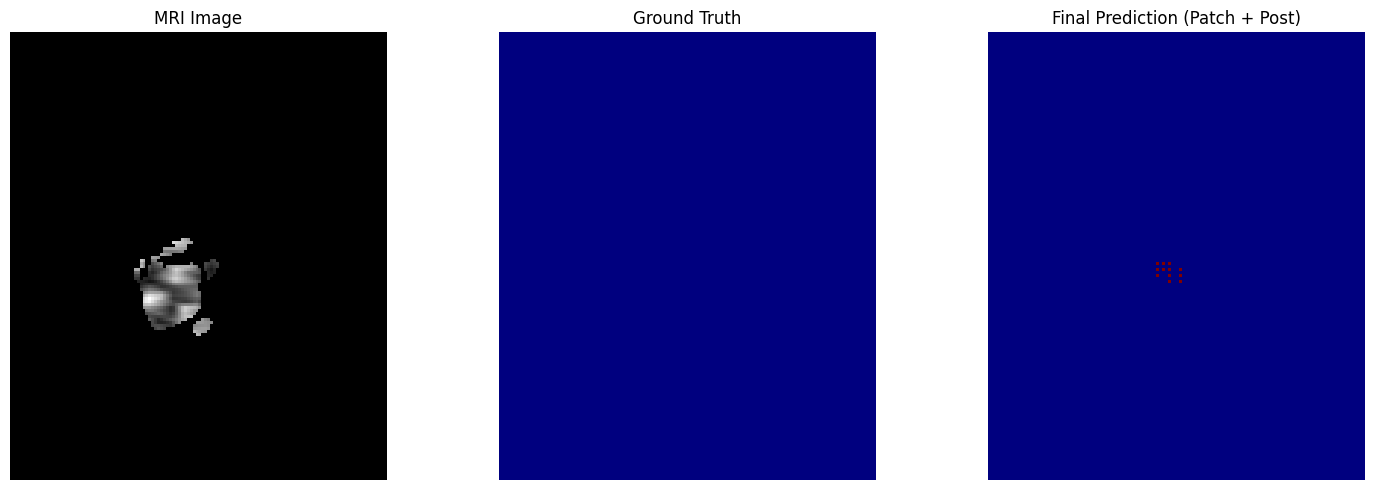

In [52]:
# Random Visualization:

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

model_3d.eval()

#random patient
i = random.choice(test_idx)
print("Patient index:", i)

img = proc_images[i]
label = proc_labels[i]

# resize
img, label = crop_to_multiple_of_8(img, label)

# label fix
label = np.where(label == 4, 3, label)

# input
img_input = np.transpose(img, (3,0,1,2))
img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

# PREDICTION
with torch.no_grad():
    out = model_3d(img_input)

    probs = torch.softmax(out, dim=1)
    conf, pred = torch.max(probs, dim=1)

    pred = pred.squeeze().cpu().numpy()
    conf = conf.squeeze().cpu().numpy()

    #FINAL BEST THRESHOLD (BACK TO 0.55)
    pred[conf < 0.55] = 0

    # post-processing
    pred = post_process_prediction(pred)

# SMART SLICE SELECTION
slice_idx = None

for s in range(label.shape[0]):
    if np.sum(label[s]) > 0 or np.sum(pred[s]) > 0:
        slice_idx = s
        break

if slice_idx is None:
    slice_idx = label.shape[0] // 2

print("Selected slice:", slice_idx)

# VISUALIZATION

img_slice = img[slice_idx, :, :, 0]
gt_slice = label[slice_idx]
pred_slice = pred[slice_idx]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_slice, cmap='gray', interpolation='nearest')
plt.title("MRI Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gt_slice, cmap='jet', interpolation='nearest')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_slice, cmap='jet', interpolation='nearest')
plt.title("Final Prediction (Patch + Post)")
plt.axis('off')

plt.tight_layout()
plt.show()


Slice index: 4


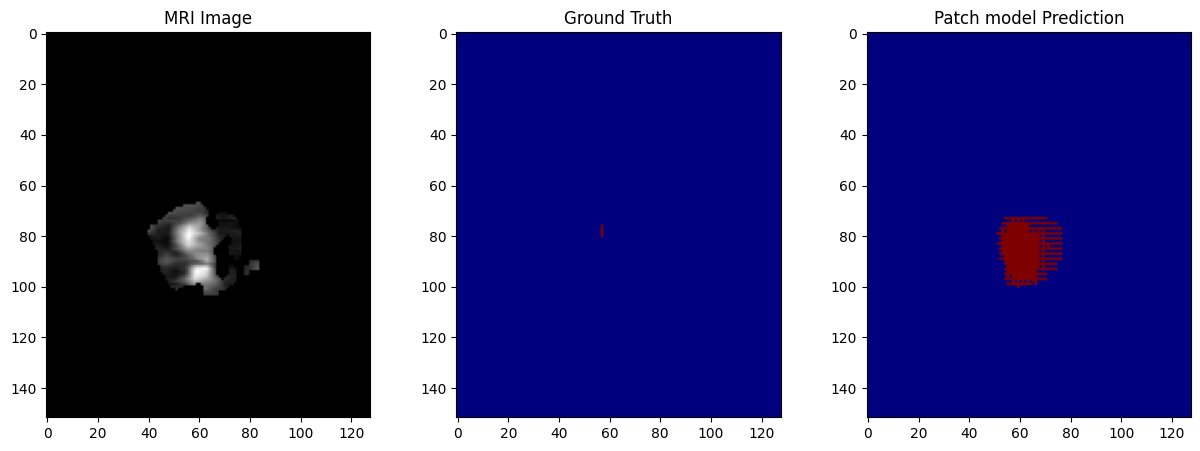

In [47]:
# Simple Visualization

import random
import torch
import numpy as np
import matplotlib.pyplot as plt

model_3d.eval()

#test sample random 
i = random.choice(test_idx)

img = proc_images[i]
label = proc_labels[i]

# resize
img, label = crop_to_multiple_of_8(img, label)

# label fix
label = np.where(label == 4, 3, label)

# input convert
img_input = np.transpose(img, (3,0,1,2))
img_input = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0)

# SIMPLE PREDICTION 

with torch.no_grad():
    out = model_3d(img_input)
    probs = torch.softmax(out, dim=1)
    conf, pred = torch.max(probs, dim=1)

    pred = pred.squeeze().cpu().numpy()
    conf = conf.squeeze().cpu().numpy()

    pred[conf < 0.55] = 0
    pred = post_process_prediction(pred)
    
# SLICE auto detect
slice_idx = 0
for s in range(label.shape[0]):
    if np.sum(label[s]) > 0:
        slice_idx = s
        break
print("Slice index:", slice_idx)

# VISUALIZATION
img_slice = img[slice_idx, :, :, 0]
gt_slice = label[slice_idx]
pred_slice = pred[slice_idx]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_slice, cmap='gray')
plt.title("MRI Image")

plt.subplot(1,3,2)
plt.imshow(gt_slice, cmap='jet')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_slice, cmap='jet')
plt.title("Patch model Prediction")

plt.show()